In [21]:
import numpy as np
from util.DataGen import nai_pulse, sample_shift_to_phase_shift, continuous_time_trace
from util.Processing import fft_deconvolve, td_nnlsr_deconvolve
import scipy
from scipy.linalg import circulant
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

import torch

In [22]:
pulse_times, pulse = nai_pulse(1)
pulse_times = pulse_times[:-1]
pulse = pulse[:-1]
kernel = pulse
print('Pulse Peak Offset:', np.argmax(pulse))

peak_offset_samples = np.argmax(pulse)
peak_offset_time = pulse_times[peak_offset_samples]

Pulse Peak Offset: 9


Trace Size: 4101


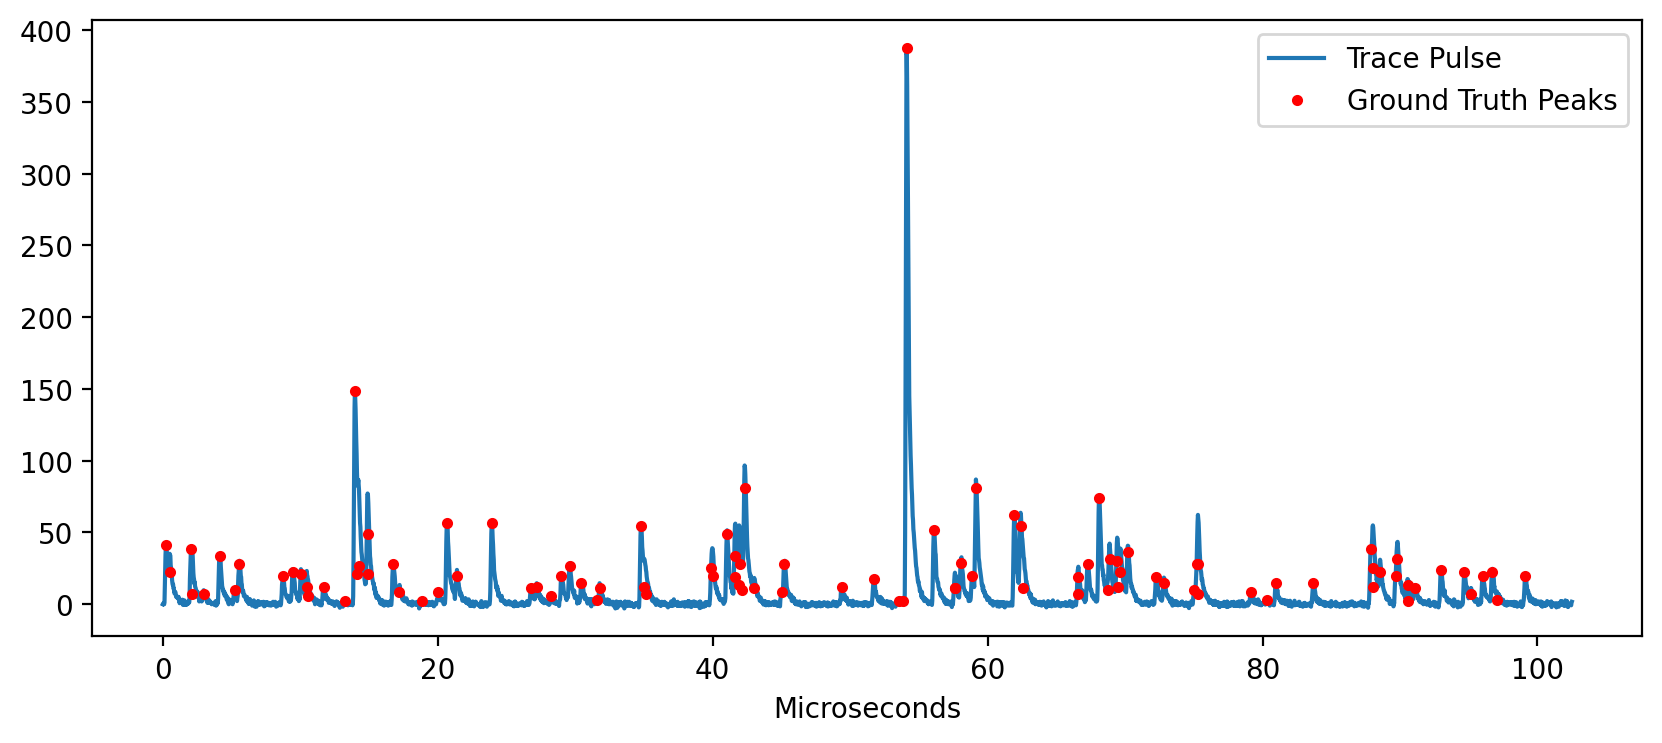

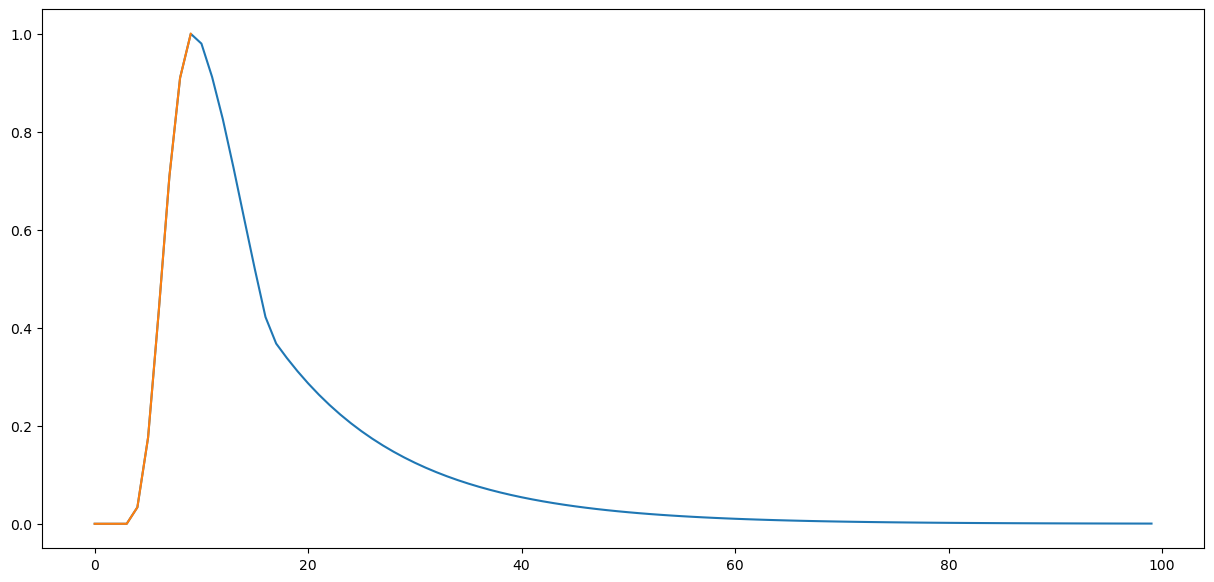

In [23]:
#determined by trial and error to match energy range of instrument on THOR data.
# modified for sampling rate difference with HERA

keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise = 1 # mV
bits = 12
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 1E-4
count_rate = 1E6

# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007 #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

response_file = 'original/NaI_Response'
spectrum = np.loadtxt(response_file,usecols=(1),dtype=float) # histogram density, unitless
binenergies = np.loadtxt(response_file,usecols=(0),dtype=float) * 1e3 # [KeV]

# 2000E6 seems right at the moment, but why?
out = continuous_time_trace(pulse, binenergies, spectrum, mV_per_ADC, keV_per_area,
                            fs=fs, count_rate=count_rate, total_time=total_time, trace_type='constant', spectrum_interp_bins=4,
                            lognormal_mean=mean, lognormal_std=std, lognormal_fwhm=fwhm,
                            baseline=baseline, basenoise=basenoise, bits=bits, clip_magnitude=clip, 
                            seed=1,)

trace, sample_t, sample_index, event_voltages, event_energies, event_times = out

print('Trace Size:', trace.size)

trace_gt0 = trace[trace>0]

fig = plt.figure(figsize=(10,4), dpi=200)
plt.plot(1E6*sample_t, trace, label='Trace Pulse')
if event_voltages.size < 20:
    microseconds = 1E6*(event_times+peak_offset_time)
    plt.plot(microseconds, event_voltages, 'r.', label='Ground Truth Peaks')
    for i in range(event_times.size):
        
        t = microseconds[i] + 1
        v = event_voltages[i]
        plt.text(t,v, 'T={:.3f}'.format(t))
else:
    microseconds = 1E6*(event_times+peak_offset_time)
    plt.plot(microseconds, event_voltages, 'r.', label='Ground Truth Peaks')
plt.xlabel('Microseconds')
plt.legend()
# plt.xlim(75, 80)

unique = np.unique(trace)
diff = np.diff(unique)[:30]
diff = np.round(diff, 6)
assert np.all(diff[0] == diff)
assert int(np.round(np.log2(1000/diff[0]))) == bits
# If correct diff: 1000 / 2^x = diff

plt.figure()
plt.plot(pulse)
rise_template = pulse[:np.argmax(pulse)+1]
plt.plot(rise_template)


In [24]:
deconv = td_nnlsr_deconvolve(trace, kernel)

MICRO = 1E6
microseconds = sample_t * MICRO


(0.0, 200.0)

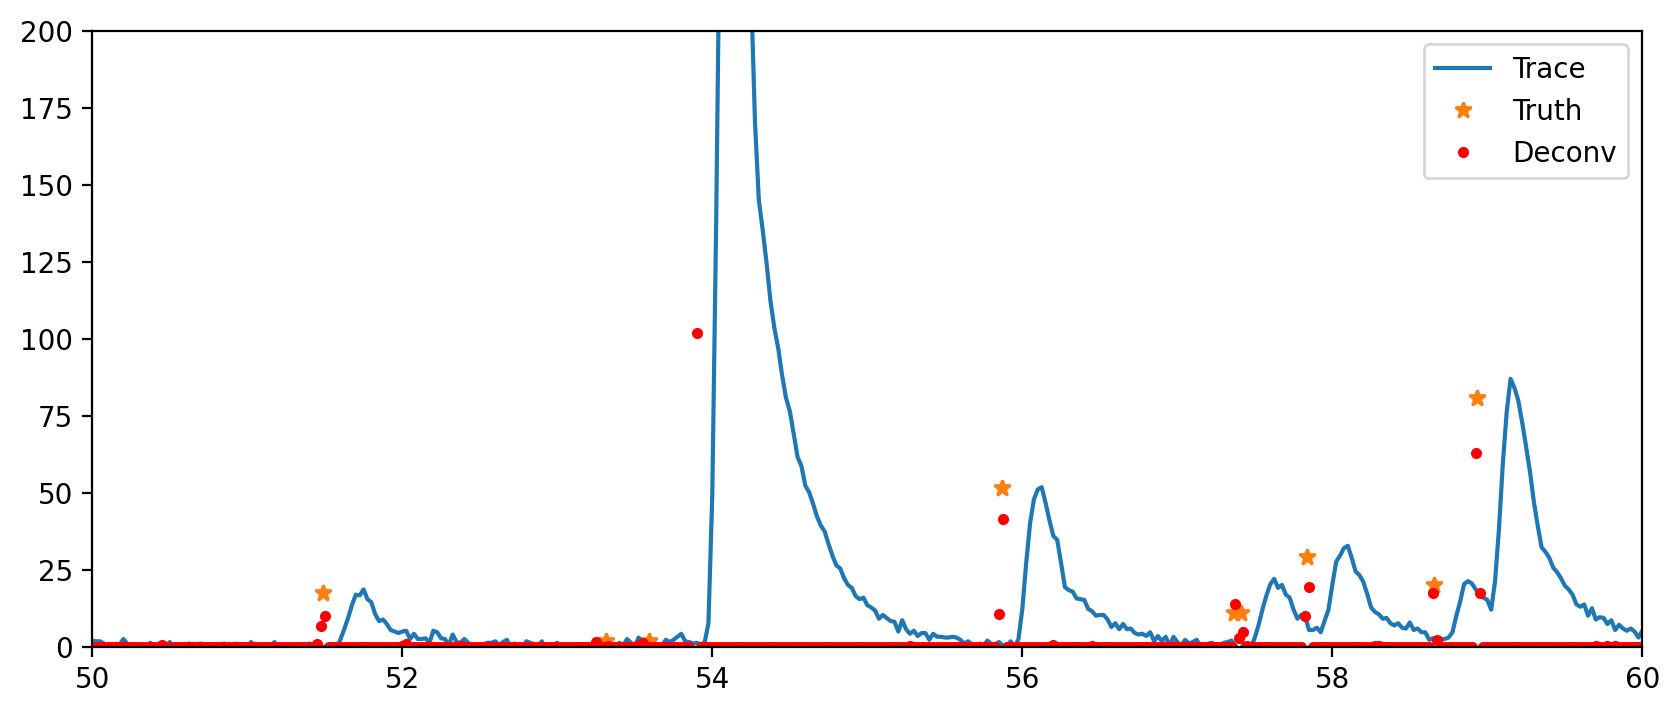

In [57]:
thresh = 0
thresh_valid_index = deconv >= thresh

fig = plt.figure(figsize=(10,4), dpi=200)
plt.plot(microseconds, trace, label='Trace')
plt.plot(MICRO * event_times, event_voltages, '*', label='Truth')
plt.plot(microseconds[thresh_valid_index], deconv[thresh_valid_index], '.', color='red', label='Deconv')
# plt.plot(microseconds, deconv, color='red', label='Deconv', alpha=.25)

plt.legend()
# plt.xlim(0,20)
# plt.xlim(40,60)
# plt.xlim(60,80)
# plt.xlim(80,100)

# plt.xlim(0,10)
# plt.xlim(10,20)
# plt.xlim(20,30)
# plt.xlim(30,40)
# plt.xlim(40,50)
plt.xlim(50,60)
# plt.xlim(60,70)
# plt.xlim(70,80)
# plt.xlim(80,90)
# plt.xlim(90,100)

plt.ylim(0,200)